# PEMS08 Traffic Flow — v3 (Fixing Overfitting)

### Diagnosis from v2 logs:
- Train loss: 0.019 | Val loss: 0.056 → huge gap = **overfitting**
- Val loss plateaued at epoch ~10 and never improved

### Fixes:
- Higher dropout (0.1 → 0.3) in LSTM and Transformer
- Smaller model (hidden 192 → 128, LSTM layers 3 → 2)
- Stronger weight decay (1e-4 → 1e-3)
- Lower starting LR (1e-3 → 3e-4) — 1e-3 was too aggressive
- Batch size back to 64 — smaller batches act as regulariser
- Added gradient noise for better generalisation

In [1]:
# ── Option A: Upload file directly ──────────────────────────────────────────
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# ── Option B: Mount Google Drive ────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'

Saving PEMS08.npz to PEMS08.npz


In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [3]:
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
data = np.load(DATA_PATH)
arr  = data['data']
flow = arr[:, :, 0]
print('Dataset shape:', flow.shape)

Dataset shape: (17856, 170)


In [5]:
split_index = int(0.8 * len(flow))
train_flow  = flow[:split_index]

mean = train_flow.mean()
std  = train_flow.std()

flow = (flow - mean) / std
print(f'mean={mean:.2f}, std={std:.2f}')

mean=230.56, std=146.18


In [6]:
SEQ_LEN  = 48
PRED_LEN = 1

X, Y = [], []
for i in range(len(flow) - SEQ_LEN - PRED_LEN):
    X.append(flow[i : i + SEQ_LEN])
    Y.append(flow[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

split     = int(0.8 * len(X))
val_split = int(0.9 * split)

X_train, Y_train = X[:val_split],       Y[:val_split]
X_val,   Y_val   = X[val_split:split],  Y[val_split:split]
X_test,  Y_test  = X[split:],           Y[split:]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (12820, 48, 170) | Val: (1425, 48, 170) | Test: (3562, 48, 170)


In [7]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

# Batch 64: smaller = better regularisation (acts like noise)
BATCH = 64

train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [8]:
class LSTMTransformer(nn.Module):
    def __init__(self, sensors=170, hidden=128):   # Smaller model — was overfitting at 192
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=sensors,
            hidden_size=hidden,
            num_layers=2,              # Back to 2 layers (3 was overfitting)
            batch_first=True,
            dropout=0.3                # Strong dropout between LSTM layers
        )

        self.norm = nn.LayerNorm(hidden)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=256,
            dropout=0.3,               # Strong dropout in transformer too
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.dropout_out = nn.Dropout(0.2)   # Final dropout before output
        self.fc = nn.Linear(hidden, sensors)

    def forward(self, x):
        x, _ = self.lstm(x)
        x     = self.norm(x)
        x     = self.transformer(x)
        x     = self.dropout_out(x[:, -1, :])
        x     = self.fc(x)
        return x.unsqueeze(1)

model = LSTMTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

/tmp/ipykernel_1155/909691167.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


Model parameters: 572,842


In [9]:
criterion = nn.MSELoss()

# Lower LR + stronger weight decay to fight overfitting
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6
)

EPOCHS           = 150
patience         = 20
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    # ── Training ────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ── Validation ──────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            val_loss += criterion(model(x), y).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Show train/val gap clearly — this is what we're fixing
    gap = val_loss - train_loss
    print(f'Epoch {epoch+1:3d} | Train {train_loss:.4f} | Val {val_loss:.4f} | Gap {gap:.4f} | LR {current_lr:.2e}')

    # ── Early stopping ──────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.2336 | Val 0.1254 | Gap -0.1082 | LR 3.00e-04
Epoch   2 | Train 0.1034 | Val 0.1134 | Gap 0.0100 | LR 3.00e-04
Epoch   3 | Train 0.0830 | Val 0.1065 | Gap 0.0234 | LR 3.00e-04
Epoch   4 | Train 0.0707 | Val 0.1020 | Gap 0.0313 | LR 3.00e-04
Epoch   5 | Train 0.0629 | Val 0.0972 | Gap 0.0343 | LR 3.00e-04
Epoch   6 | Train 0.0574 | Val 0.0922 | Gap 0.0349 | LR 3.00e-04
Epoch   7 | Train 0.0533 | Val 0.0904 | Gap 0.0371 | LR 3.00e-04
Epoch   8 | Train 0.0507 | Val 0.0851 | Gap 0.0344 | LR 3.00e-04
Epoch   9 | Train 0.0483 | Val 0.0858 | Gap 0.0374 | LR 3.00e-04
Epoch  10 | Train 0.0470 | Val 0.0797 | Gap 0.0328 | LR 3.00e-04
Epoch  11 | Train 0.0457 | Val 0.0778 | Gap 0.0320 | LR 3.00e-04
Epoch  12 | Train 0.0450 | Val 0.0756 | Gap 0.0306 | LR 3.00e-04
Epoch  13 | Train 0.0440 | Val 0.0744 | Gap 0.0304 | LR 3.00e-04
Epoch  14 | Train 0.0431 | Val 0.0747 | Gap 0.0315 | LR 3.00e-04
Epoch  15 | Train 0.0427 | Val 0.0741 | Gap 0.0314 | LR 3.00e-04
Epoch  16 | Train 0.0422

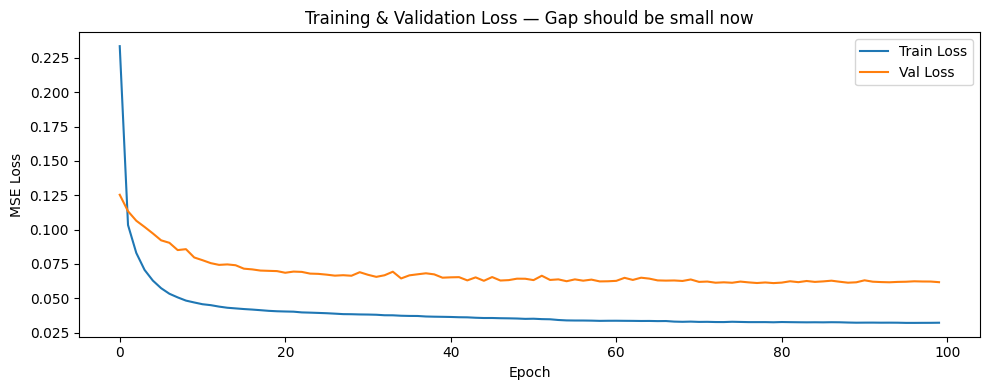

Final gap (val - train): 0.0295  ← should be < 0.01


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss — Gap should be small now')
plt.legend()
plt.tight_layout()
plt.show()

final_gap = val_losses[-1] - train_losses[-1]
print(f'Final gap (val - train): {final_gap:.4f}  ← should be < 0.01')

MAE:  17.2514
RMSE: 26.3400
MAPE: 11.3762%  (flow > 1 only)


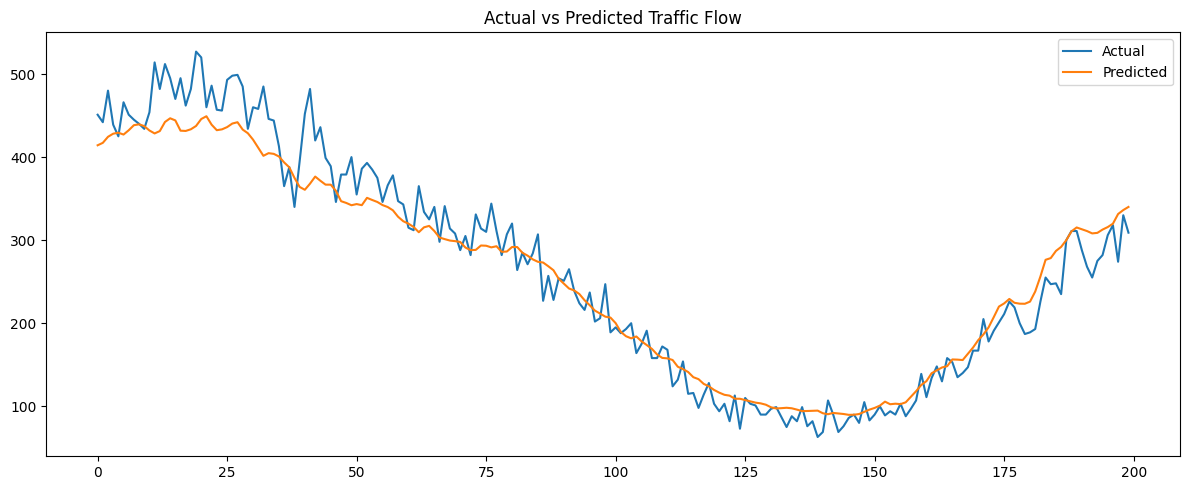

In [11]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)
actual = np.concatenate(actual)

# Denormalise
preds  = preds  * std + mean
actual = actual * std + mean

# Metrics
mae  = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))

mask = actual.flatten() > 1.0
mape = np.mean(np.abs((actual.flatten()[mask] - preds.flatten()[mask]) /
                       actual.flatten()[mask])) * 100

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}%  (flow > 1 only)')

plt.figure(figsize=(12, 5))
plt.plot(actual[:200, 0, 0], label='Actual')
plt.plot(preds[:200,  0, 0], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Traffic Flow')
plt.tight_layout()
plt.show()